In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Setup completato ✓")

Setup completato ✓


# ⚽ International Football Results — Analisi storica del calcio internazionale

**Nome e cognome**: Andres Pelizzer
**Dataset scelto**: International Football Results (1872–2025)
**Link Kaggle**: https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017

**Perché ho scelto questo dataset**: Sono un appassionato di calcio e volevo scoprire cosa si nasconde dietro 150 anni di partite internazionali — dal fattore campo al record dell'Italia.

---

### 📋 Le 5 domande di ricerca

1. **Q1** — Quante partite totali, quante nazionali, quanti tornei diversi? In che anno è la prima partita registrata?
2. **Q2** — Quali nazionali hanno vinto più partite di sempre? E con la più alta percentuale di vittorie (su almeno 100 partite)?
3. **Q3** — Il record dell'Italia: quante partite, vittorie/pareggi/sconfitte, qual è stato il decennio migliore e quello peggiore?
4. **Q4** — Esiste davvero il "fattore campo"? Le squadre di casa vincono più spesso? Nei tornei in campo neutrale come cambia?
5. **Q5** — Il calcio è diventato più offensivo o più difensivo nel tempo? Come è cambiato il numero medio di gol per partita dal 1900 a oggi?

**Bonus**: Le grandi rivalità — le 10 coppie di nazionali che si sono affrontate più volte, con il bilancio per ognuna.

In [5]:
df = pd.read_csv("results.csv")
print(f"Dataset caricato: {df.shape[0]} righe × {df.shape[1]} colonne")
df.head()

Dataset caricato: 49287 righe × 9 colonne


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [7]:
df.describe()

,home_score,away_score
count,49215.000000,49215.000000
mean,1.756091,1.182404
std,1.770617,1.401770
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [8]:
tutte_le_squadre = pd.concat([df['home_team'], df['away_team']]).nunique()

print(f"Partite totali: {df.shape[0]}")
print(f"Nazionali diverse: {tutte_le_squadre}")
print(f"Tornei diversi: {df['tournament'].nunique()}")
print(f"Periodo: da {df['date'].min()} a {df['date'].max()}")

Partite totali: 49287
Nazionali diverse: 333
Tornei diversi: 193
Periodo: da 1872-11-30 a 2026-06-27


### 📝 Risposta Q1

Il dataset contiene **49.287 partite internazionali** disputate tra il 30 novembre 1872 e il 27 giugno 2026, coprendo oltre 150 anni di calcio. Sono presenti **333 nazionali diverse** e **193 tornei** (dalle amichevoli ai Mondiali). Le colonne chiave sono: data, squadra di casa/ospite, gol, torneo, città, paese e se il campo è neutro.

Da notare: 72 partite non hanno il risultato (gol mancanti) e la colonna `date` è salvata come stringa, va convertita. Il gol massimo registrato in casa è 31 — ci sono goleade estreme che potrebbero essere outlier da investigare.

## 🧹 Pulizia del dataset

In [ ]:
# 1. Convertiamo la colonna date in formato datetime, questo ci sblocca .dt.year .dt.month ecc
df['date'] = pd.to_datetime(df['date'])

# 2. Vediamo i valori mancanti
print("Valori mancanti per colonna:")
print(df.isna().sum())

# 3. Controlliamo i duplicati
print(f"\nRighe duplicate: {df.duplicated().sum()}")

Valori mancanti per colonna:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

Righe duplicate: 0


In [ ]:
# Rimozione 72 partite senza risultato
df=df.dropna(subset=["home_score","away_score"])

# Convertire i gol in interi ( ora che non ci sono più Nan si può). Pandas essendoci i Nan (Not a Number) li convertiva automaticamente in decimali.
df["home_score"]=df["home_score"].astype(int)
df["away_score"]=df["away_score"].astype(int)

# Creiamo colonne utili per dopo
df["total_goals"]= df["home_score"] + df["away_score"]
df["year"]=df["date"].dt.year

print(f"Righe dopo pulizia:{df.shape[0]}")
print(f"Tipi aggiornati:")
print(df[["home_score","away_score","total_goals","year"]].dtypes)


Righe dopo pulizia:49215
Tipi aggiornati:
home_score     int64
away_score     int64
total_goals    int64
year           int32
dtype: object


### 📝 Pulizie effettuate

- **Convertita la colonna `date`** da stringa a datetime per poter estrarre anno, mese e decennio
- **Rimosse 72 partite** senza risultato (gol mancanti): sono lo 0.15% del dataset, irrilevanti
- **Convertiti i gol** da float a int, ora che i NaN non li forzano più in decimale
- **Create 2 colonne nuove**: `total_goals` (somma gol della partita) e `year` (anno), utili per le analisi temporali

## 📊 Q2 — Quali nazionali hanno vinto più partite? E con la più alta percentuale di vittorie?

In [11]:
vittorie_casa = df[df['home_score'] > df['away_score']]['home_team'].value_counts()
vittorie_fuori = df[df['away_score'] > df['home_score']]['away_team'].value_counts()
vittorie_totali=vittorie_casa.add(vittorie_fuori,fill_value=0).astype(int).sort_values(ascending=False)
vittorie_totali.head(10)

home_team
Brazil         670
England        623
Germany        597
Argentina      588
Sweden         541
South Korea    536
Mexico         511
France         476
Italy          475
Hungary        470
Name: count, dtype: int64

In [12]:
partite_casa = df['home_team'].value_counts()
partite_fuori = df['away_team'].value_counts()
partite_totali=partite_casa.add(partite_fuori, fill_value=0).astype(int)

percentuale_vittorie=(vittorie_totali/partite_totali *100).round(1)
percentuale_vittorie = percentuale_vittorie[partite_totali >= 100].sort_values(ascending=False)

percentuale_vittorie.head(10)


home_team
Jersey       65.1
Brazil       63.4
Guernsey     60.4
Spain        58.9
Germany      58.0
England      57.3
Iran         56.9
Argentina    55.3
Tahiti       54.1
Italy        53.3
Name: count, dtype: float64

C:\Users\andres.pelizzer_alli\AppData\Local\Temp\ipykernel_11948\1617974706.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_vittorie.values, y=top10_vittorie.index, ax=axes[0],palette="Blues_r")
C:\Users\andres.pelizzer_alli\AppData\Local\Temp\ipykernel_11948\1617974706.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_perc.values, y=top10_perc.index, ax=axes[1],palette="Greens_r")


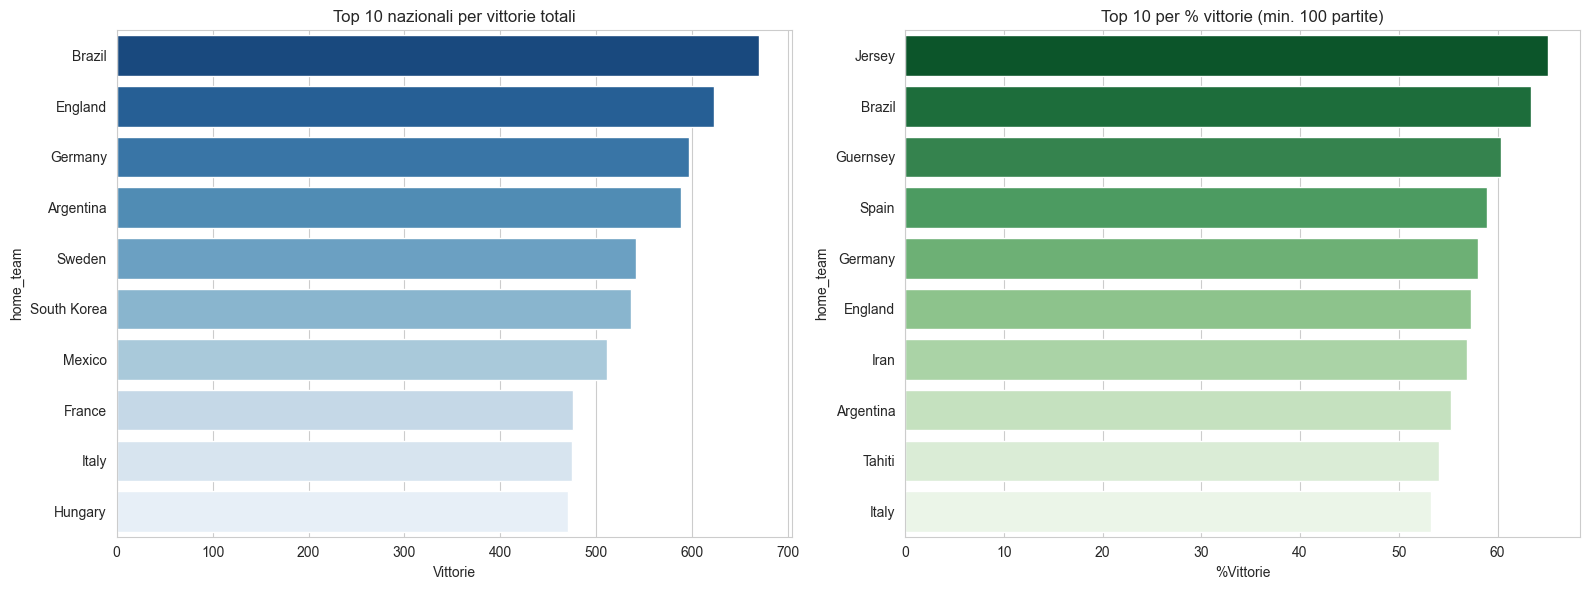

In [13]:
fig, axes= plt.subplots(1, 2, figsize=(16,6))

# Grafico 1: Top 10 per vittorie totali

top10_vittorie=vittorie_totali.head(10)
sns.barplot(x=top10_vittorie.values, y=top10_vittorie.index, ax=axes[0],palette="Blues_r")
axes[0].set_title("Top 10 nazionali per vittorie totali")
axes[0].set_xlabel("Vittorie")

# Grafico 2: Top 10 per percentuale vittorie
top10_perc=percentuale_vittorie.head(10)
sns.barplot(x=top10_perc.values, y=top10_perc.index, ax=axes[1],palette="Greens_r")
axes[1].set_title("Top 10 per % vittorie (min. 100 partite)")
axes[1].set_xlabel("%Vittorie")

plt.tight_layout()
plt.show()




### 📝 Risposta Q2

Il **Brasile** è la nazionale con più vittorie in assoluto (670), seguita da Inghilterra (623) e Germania (597). L'Italia è nona con 475 vittorie.

In percentuale di vittorie però la classifica cambia: Jersey (65.1%) e Guernsey (60.4%) guidano, ma sono squadre che giocano quasi solo in tornei minori tra isole. Tra le grandi nazionali, il **Brasile** conferma il primato con il 63.4%, seguito da Spagna (58.9%) e Germania (58.0%). L'Italia ha una percentuale del 53.3% — vince poco più di una partita su due.

## 🇮🇹 Q3 — Il record dell'Italia: vittorie, pareggi, sconfitte e il decennio migliore/peggiore

In [14]:
italia = df[(df['home_team'] == 'Italy') | (df['away_team'] == 'Italy')]
print(f"Partite dell'Italia: {italia.shape[0]}")

Partite dell'Italia: 891


In [15]:
# Creiamo una colonna "risultato" dal punto di vista dell'Italia
def risultato_italia(row):
    if row['home_score'] == row['away_score']:
        return 'Pareggio'
    elif (row['home_team'] == 'Italy' and row['home_score'] > row['away_score']) or \
         (row['away_team'] == 'Italy' and row['away_score'] > row['home_score']):
        return 'Vittoria'
    else:
        return 'Sconfitta'

italia['risultato'] = italia.apply(risultato_italia, axis=1)
italia['risultato'].value_counts()


risultato
Vittoria     475
Pareggio     243
Sconfitta    173
Name: count, dtype: int64

In [16]:
# Creiamo la colonna decennio (1900, 1910, 1920, ...)
italia['decennio'] = (italia['year'] // 10) * 10

# Percentuale vittorie per decennio
record_decennio = italia.groupby('decennio')['risultato'].value_counts(normalize=True).unstack(fill_value=0)
record_decennio['% Vittorie'] = (record_decennio['Vittoria'] * 100).round(1)

print(record_decennio['% Vittorie'].sort_values(ascending=False))

decennio
1930    68.2
1940    63.2
1960    61.3
2020    56.8
2000    56.7
1990    55.2
1970    52.9
1980    49.5
2010    48.0
1920    45.2
1950    40.4
1910    36.4
Name: % Vittorie, dtype: float64


C:\Users\andres.pelizzer_alli\AppData\Local\Temp\ipykernel_11948\2964372007.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decenni_ordinati.index.astype(str), y=decenni_ordinati.values, palette=colori)


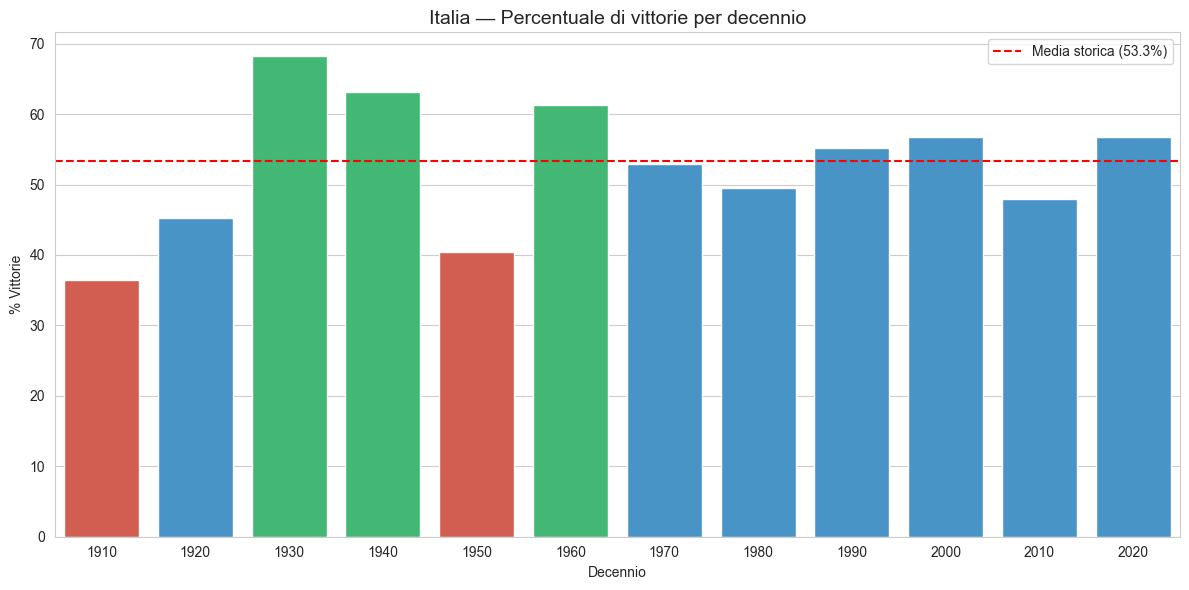

In [ ]:
# 1. Creiamo la figura — figsize imposta larghezza e altezza in pollici
plt.figure(figsize=(12, 6))

# 2. Prendiamo le % vittorie ordinate per decennio (1910, 1920, 1930, ...)
#    sort_index() ordina per decennio, non per valore
decenni_ordinati = record_decennio['% Vittorie'].sort_index()

# 3. Assegniamo un colore a ogni barra in base alla percentuale:
#    - Verde se >= 60% (decenni top)
#    - Rosso se < 45% (decenni brutti)
#    - Blu per quelli nella media
colori = []
for v in decenni_ordinati.values:
    if v >= 60:
        colori.append('#2ecc71')    # verde
    elif v < 45:
        colori.append('#e74c3c')    # rosso
    else:
        colori.append('#3498db')    # blu

# 4. Creiamo il grafico a barre
#    x = i decenni (convertiti in stringa per l'etichetta)
#    y = la percentuale di vittorie
sns.barplot(x=decenni_ordinati.index.astype(str), y=decenni_ordinati.values, palette=colori)

# 5. Titolo e etichette degli assi 
plt.title("Italia — Percentuale di vittorie per decennio", fontsize=14)
plt.xlabel("Decennio")
plt.ylabel("% Vittorie")

# 6. Linea tratteggiata rossa alla media storica dell'Italia (53.3%)
#    Serve come riferimento visivo: sopra la linea = sopra la media
plt.axhline(y=53.3, color='red', linestyle='--', label='Media storica (53.3%)')

# 7. Mostra la legenda (spiega cosa è la linea rossa)
plt.legend()

# 8. Aggiusta i margini automaticamente
plt.tight_layout()

# 9. Mostra il grafico
plt.show()


### 📝 Risposta Q3

L'Italia ha disputato **891 partite internazionali**: 475 vittorie, 243 pareggi e 173 sconfitte (percentuale vittorie: 53.3%).

Il **decennio migliore** è il 1930 (68.2% di vittorie), periodo in cui l'Italia vinse due Mondiali consecutivi (1934 e 1938). Anche gli anni '40 e '60 sono stati eccellenti. Il **decennio peggiore** è il 1910 (36.4%), quando il calcio italiano era ancora alle prime armi. Sorprende il calo degli anni 2010 (48.0%), coinciso con la mancata qualificazione ai Mondiali 2018.

## 🏟️ Q4 — Esiste il "fattore campo"? Le squadre di casa vincono più spesso?

In [21]:
vittorie_casa = df[df['home_score'] > df['away_score']].shape[0]
vittorie_fuori = df[df['away_score'] > df['home_score']].shape[0]
pareggi = df[df['home_score'] == df['away_score']].shape[0]

totale = df.shape[0]
print(f"Vittorie casa:  {vittorie_casa} ({vittorie_casa/totale*100:.1f}%)")
print(f"Vittorie fuori: {vittorie_fuori} ({vittorie_fuori/totale*100:.1f}%)")
print(f"Pareggi:        {pareggi} ({pareggi/totale*100:.1f}%)")

Vittorie casa:  24106 (49.0%)
Vittorie fuori: 13912 (28.3%)
Pareggi:        11197 (22.8%)


In [22]:
# Partite in campo neutro vs non neutro
neutro = df[df['neutral'] == True]
non_neutro = df[df['neutral'] == False]

# Vittorie casa su campo NON neutro
vit_casa_nn = non_neutro[non_neutro['home_score'] > non_neutro['away_score']].shape[0]
print(f"Campo NON neutro — Vittorie casa: {vit_casa_nn/non_neutro.shape[0]*100:.1f}%")

# Vittorie casa su campo neutro
vit_casa_n = neutro[neutro['home_score'] > neutro['away_score']].shape[0]
print(f"Campo NEUTRO    — Vittorie casa: {vit_casa_n/neutro.shape[0]*100:.1f}%")

Campo NON neutro — Vittorie casa: 50.7%
Campo NEUTRO    — Vittorie casa: 44.1%


C:\Users\andres.pelizzer_alli\AppData\Local\Temp\ipykernel_11948\3591935881.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categorie, y=valori, palette=colori, ax=axes[0])
C:\Users\andres.pelizzer_alli\AppData\Local\Temp\ipykernel_11948\3591935881.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_labels, y=vittorie_casa_perc, palette=['#2ecc71', '#95a5a6'], ax=axes[1])


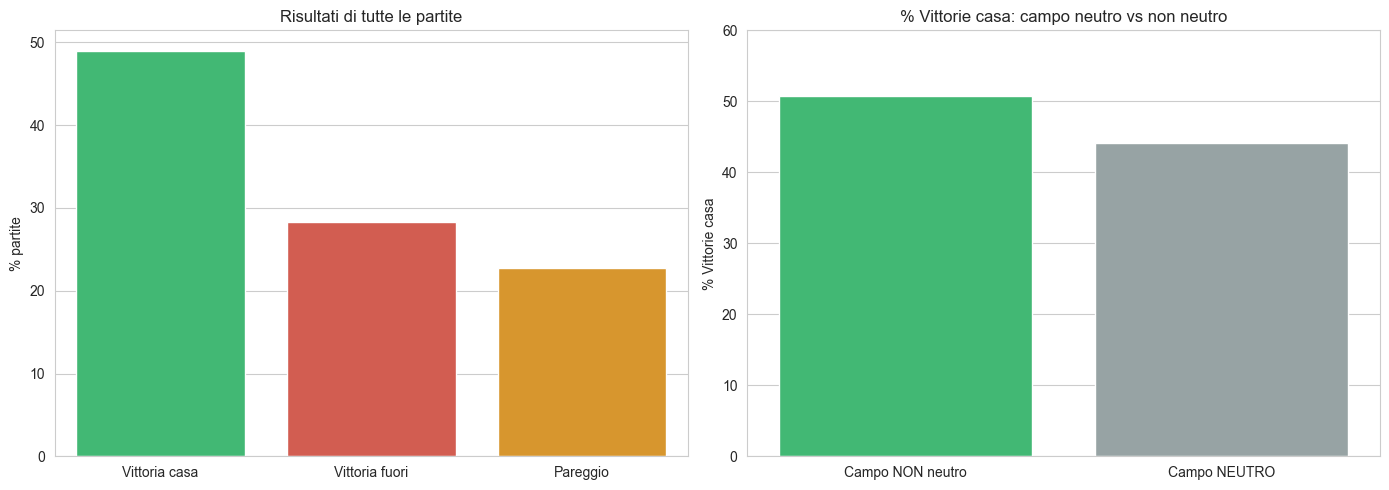

In [23]:
# Dati per il grafico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Distribuzione generale (casa/fuori/pareggio)
categorie = ['Vittoria casa', 'Vittoria fuori', 'Pareggio']
valori = [49.0, 28.3, 22.8]
colori = ['#2ecc71', '#e74c3c', '#f39c12']
sns.barplot(x=categorie, y=valori, palette=colori, ax=axes[0])
axes[0].set_title("Risultati di tutte le partite")
axes[0].set_ylabel("% partite")

# Grafico 2: Confronto neutro vs non neutro
x_labels = ['Campo NON neutro', 'Campo NEUTRO']
vittorie_casa_perc = [50.7, 44.1]
sns.barplot(x=x_labels, y=vittorie_casa_perc, palette=['#2ecc71', '#95a5a6'], ax=axes[1])
axes[1].set_title("% Vittorie casa: campo neutro vs non neutro")
axes[1].set_ylabel("% Vittorie casa")
axes[1].set_ylim(0, 60)

plt.tight_layout()
plt.show()

### 📝 Risposta Q4

Il fattore campo **esiste ed è forte**: la squadra di casa vince nel 49.0% dei casi, contro il 28.3% degli ospiti e il 22.8% di pareggi. In pratica, giocare in casa quasi raddoppia le probabilità di vittoria rispetto a giocare fuori.

Confrontando campo neutro e non neutro, la percentuale di vittorie casalinghe scende dal 50.7% al 44.1% — conferma che parte del vantaggio viene dal giocare davanti al proprio pubblico e nel proprio stadio.

## ⚽ Q5 — Il calcio è diventato più offensivo o difensivo? Come cambia il numero medio di gol per partita dal 1900 a oggi?

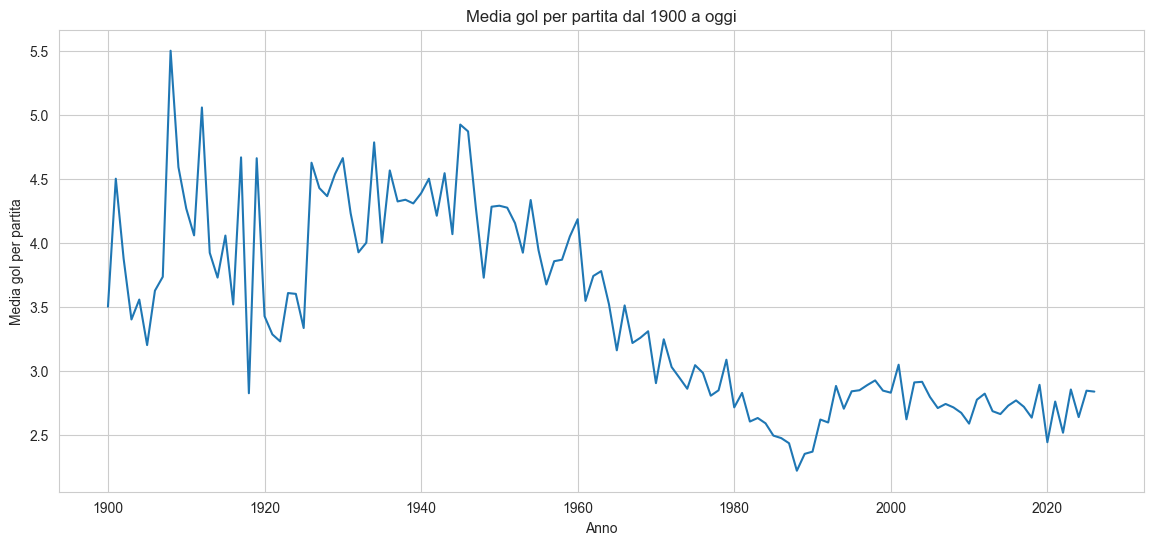

In [24]:
partite_1900 = df[df["year"] >= 1900]
gol_per_anno = partite_1900.groupby("year")["total_goals"].mean()

# Grafico
plt.figure(figsize=(14, 6))
sns.lineplot(x=gol_per_anno.index, y=gol_per_anno.values)
plt.title("Media gol per partita dal 1900 a oggi")
plt.xlabel("Anno")
plt.ylabel("Media gol per partita")
plt.show()

### 📝 Risposta Q5

Il calcio è diventato **più difensivo** nel tempo. Nei primi decenni del 1900 si segnavano in media 4-5 gol a partita, con picchi sopra i 5.5 gol. Dal secondo dopoguerra in poi la media è scesa progressivamente, stabilizzandosi attorno ai **2.5-3 gol per partita** dagli anni '60 in avanti.

Questo riflette l'evoluzione tattica del calcio: dalle formazioni ultra-offensive dei primi tempi si è passati a sistemi più strutturati e difensivi (il catenaccio italiano negli anni '60, la zona negli anni '80, il pressing moderno). Oggi il calcio è più atletico e tattico, ma si segna meno della metà rispetto a un secolo fa.

## 🎯 Conclusioni e insight chiave

**🥇 Insight 1 — L'Italia degli anni '30 vs quella degli anni 2010**: L'Italia vinceva il 68% delle partite negli anni '30 (periodo dei due Mondiali 1934 e 1938) ma solo il 48% negli anni 2010, quando non è riuscita nemmeno a qualificarsi ai Mondiali 2018. Un calo di 20 punti percentuali che racconta il declino di una nazionale storica.

**🥈 Insight 2 — Il calcio si è dimezzato in gol**: Si è passati da una media di 5.5 gol a partita a inizio '900 a meno di 3 oggi. Un tifoso di un secolo fa vedeva il doppio dei gol rispetto a noi. L'evoluzione tattica ha reso il calcio più strategico ma meno spettacolare.

**🥉 Insight 3 — Jersey batte il Brasile (sulla carta)**: Jersey, un'isola di 100.000 abitanti, ha una percentuale di vittorie del 65.1% contro il 63.4% del Brasile. Ovviamente giocano tornei completamente diversi — ma è la dimostrazione che i numeri vanno sempre contestualizzati e non presi alla lettera.


BONUS

In [25]:
def crea_coppia(row):
    squadre = sorted([row['home_team'], row['away_team']])
    return squadre[0] + " - " + squadre[1]


df['coppia'] = df.apply(crea_coppia, axis=1)

df['coppia'].value_counts().head(10)

coppia
Argentina - Uruguay      183
Austria - Hungary        137
Belgium - Netherlands    129
Guernsey - Jersey        119
England - Scotland       118
Argentina - Brazil       110
Kenya - Uganda           110
Norway - Sweden          109
Denmark - Sweden         108
Argentina - Paraguay     107
Name: count, dtype: int64

In [26]:
top10_coppie = df['coppia'].value_counts().head(10).index

for coppia in top10_coppie:
    partite = df[df['coppia'] == coppia]
    squadra_a, squadra_b = coppia.split(" - ")
    
    vit_a = partite[
        ((partite['home_team'] == squadra_a) & (partite['home_score'] > partite['away_score'])) |
        ((partite['away_team'] == squadra_a) & (partite['away_score'] > partite['home_score']))
    ].shape[0]
    
    vit_b = partite[
        ((partite['home_team'] == squadra_b) & (partite['home_score'] > partite['away_score'])) |
        ((partite['away_team'] == squadra_b) & (partite['away_score'] > partite['home_score']))
    ].shape[0]
    
    par = partite[partite['home_score'] == partite['away_score']].shape[0]
    
    print(f"{coppia}: {squadra_a} {vit_a} - {par} - {vit_b} {squadra_b}")

Argentina - Uruguay: Argentina 85 - 44 - 54 Uruguay
Austria - Hungary: Austria 40 - 30 - 67 Hungary
Belgium - Netherlands: Belgium 41 - 31 - 57 Netherlands
Guernsey - Jersey: Guernsey 47 - 14 - 58 Jersey
England - Scotland: England 49 - 27 - 42 Scotland
Argentina - Brazil: Argentina 41 - 26 - 43 Brazil
Kenya - Uganda: Kenya 31 - 37 - 42 Uganda
Norway - Sweden: Norway 26 - 25 - 58 Sweden
Denmark - Sweden: Denmark 42 - 20 - 46 Sweden
Argentina - Paraguay: Argentina 56 - 34 - 17 Paraguay


### 📝 Risposta Bonus — Le grandi rivalità

Le 10 rivalità più giocate sono quasi tutte tra **paesi confinanti**: Argentina-Uruguay (183 partite!), Austria-Ungheria, Belgio-Olanda, Inghilterra-Scozia. Il calcio internazionale nasce come sfida tra vicini.

Alcune rivalità sono **dominate** da una squadra: l'Ungheria ha 67 vittorie contro le 40 dell'Austria, la Svezia ne ha 58 contro le 26 della Norvegia. Altre sono molto più **equilibrate**: Argentina-Brasile (41-26-43) è il classico scontro tra titani dove nessuno prevale nettamente. La rivalità più sbilanciata in termini assoluti è Argentina-Paraguay (56-17 per l'Argentina).